# **Notebook 2: Data Preprocessing**

> **Objective:** Transform raw customer and basket datasets into clean datasets prepared for the next modelling stages. The **customer dataset** is cleaned and feature-engineered for **clustering**, while the **basket dataset** is preserved at transaction level for the generation of **association rules**.

---

## **Table of Contents**
1. [Imports and Libraries](#1-imports)
2. [Load Raw Datasets](#2-load)
3. [Customer Data Cleaning Pipeline](#3-customer-pipeline)
4. [Basket Data Preparation for Association Rules](#4-basket-association-rules)
5. [Validation Checks](#5-validation)
6. [Export Processed Data](#6-export)

---


<a id="1-imports"></a>
## **1. Imports and Libraries**

In [ ]:
# to import from src folder (where our py files are located)
import sys 
sys.path.append("../src") 

# functions to clean the raw data
from datacleaning import (
    customer_clean_data,
    basket_clean_data_for_association_rules,
    check_missing, 
    check_datatypes, 
    check_numeric_ranges, 
    plot_dbscan_clusters_with_outliers,
)
# to check the current working directory                      
import os 
os.getcwd()

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

# to automatically reload the py files when they are edited
%load_ext autoreload
%autoreload 2

# to ignore warnings
import warnings
warnings.filterwarnings('ignore')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


<a id="2-load"></a>
## **2. Load Raw Datasets**

> We import the 2 raw CSV files.

It is crucial to **understand the differences** between our two primary data sources before manipulating them:
- The `customer_info` dataset is a database where **each row represents a unique individual**. Therefore, we set the **customer ID** directly as the dataframe **index** to ensure data integrity.
- The `customer_basket` dataset is a transactional log of **receipts**. A single customer can have multiple rows (representing multiple trips to the store). Thus, we load it **without** a fixed index, preserving one row per transaction for association rules.

In [2]:
raw_data_customer = pd.read_csv('../data/customer_info.csv', index_col=0) #customer id as index
raw_data_basket = pd.read_csv('../data/customer_basket.csv')

print(f"Raw customer dataset shape: {raw_data_customer.shape}") 
print(f"Raw basket dataset shape: {raw_data_basket.shape}")

Raw customer dataset shape: (33038, 24)
Raw basket dataset shape: (100000, 3)


In [3]:
raw_data_customer.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33038 entries, 3 to 40000
Data columns (total 24 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   customer_name                            33038 non-null  object 
 1   customer_gender                          33038 non-null  object 
 2   customer_birthdate                       32873 non-null  object 
 3   kids_home                                32708 non-null  float64
 4   teens_home                               32708 non-null  float64
 5   number_complaints                        32377 non-null  float64
 6   distinct_stores_visited                  32708 non-null  float64
 7   lifetime_spend_groceries                 33038 non-null  float64
 8   lifetime_spend_electronics               32377 non-null  float64
 9   typical_hour                             32377 non-null  float64
 10  lifetime_spend_vegetables                32377 non-

In [ ]:
raw_data_basket.info()

<a id="3-customer-pipeline"></a>
## **3. Customer Data Cleaning Pipeline**
> We apply the customer preprocessing pipeline defined in `datacleaning.py`. This pipeline automatically correct data types, drop impossible values, handle missing values (using advanced KNN Imputation), flags multidimensional outliers (using DBSCAN) and perform feature engineering (such as calculating customer's ages and another useful variables) for clustering.

The customer pipeline includes the following steps:
#### **Customer Info (`customer_clean_data`)**

1. **Data Types:** We convert date strings into datetime objects, floats into integers and calculate `customer_age` based on the birthdate;
2. **Impossible Values:** We "created" some strict rules. Ages must be between 1 and 120, the `typical_hour` of shopping must be during store hours (6 to 23) and count/spend variables cannot be negative. Any violations are temporarily converted to `NaN`.
3. **Missing Values:** 
   * **Zero-filling:** Missing values in the `lifetime_spend` columns are filled with 0, assuming the customer simply hasn't bought from that category.
   * **KNN Imputation (k=7):** For the other missing values, we use a K-Nearest Neighbors imputer.
4. **Outliers:** We apply **DBSCAN** with `eps=4.5` and `min_samples=10` as a diagnostic tool to identify severe multidimensional outliers. These observations are flagged in `is_customer_outlier`, but not removed, since unusual customers may still represent valid and valuable customer profiles.
5. **Feature Engineering:** We create new analytical features:
   * `education_level`: Extracted directly from the customer's title (Bsc, Msc, Phd). Unknown when there's no information.
   * `total_children`: Aggregated from the kids and teens columns.
   * `time_of_day`: Categorized based on the typical hour.


--

In [ ]:
# Run the complete cleaning pipeline
clean_customer_df = customer_clean_data(raw_data_customer)
print(f"Cleaned customer dataset shape: {clean_customer_df.shape}")


Cleaned customer dataset shape: (33038, 38)
Cleaned basket dataset shape: (28127, 8)


In [5]:
clean_customer_df['is_customer_outlier'].value_counts()

is_customer_outlier
0    33004
1       34
Name: count, dtype: int64

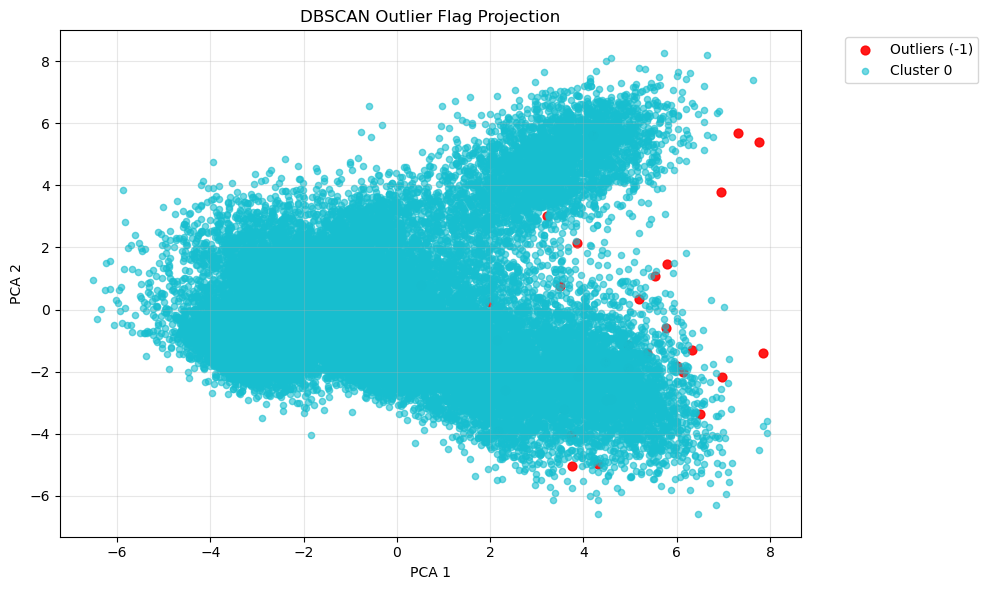

In [6]:
plot_df = clean_customer_df.copy()

numeric_cols = plot_df.select_dtypes(include='number').columns
numeric_cols = [
    col for col in numeric_cols
    if col not in ['customer_id', 'is_customer_outlier']
]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(plot_df[numeric_cols])

dbscan_labels = plot_df['is_customer_outlier'].map({
    1: -1,
    0: 0
})

plot_dbscan_clusters_with_outliers(
    X_scaled,
    dbscan_labels,
    title="DBSCAN Outlier Flag Projection"
)

In [7]:
dbscan_labels.value_counts()

is_customer_outlier
 0    33004
-1       34
Name: count, dtype: int64

#### **Observed Changes**

The customer preprocessing pipeline successfully:
1. Converted variables to appropriate data types;
2. Created new features such as `customer_age`, `years_tenure`, `total_children` and spending-share variables;
3. Corrected impossible values and handled missing values;
4. Flagged multidimensional outliers using DBSCAN in `is_customer_outlier`, without removing them.

<a id="4-basket-association-rules"></a>
## **4. Basket Data Preparation for Association Rules**
> The basket dataset is preserved at transaction level because association rules require the original basket structure. Therefore, we only remove duplicates, parse the `list_of_goods` column and create `basket_size`.

In [ ]:
basket_transactions_df = basket_clean_data_for_association_rules(raw_data_basket)

The basket dataset was prepared separately at transaction level for association rule mining. This preserves the original basket structure, where each row represents one invoice.

<a id="5-validation"></a>
## **5. Validation Checks**

> We will now perform **validation checks** on both processed datasets to verify **both pipelines were executed sucessfully.** Missing Values, Data types and our Logical Rules are checked separately for the customer dataset and the basket transaction dataset.

#### **Check 1: Missing Values**

In [ ]:
customer_missing_df, basket_missing_df = check_missing(clean_customer_df, basket_transactions_df, raw_data_customer, raw_data_basket)

display(customer_missing_df)
display(basket_missing_df)

,Missing Count (Final),Missing Count (Original)
customer_birthdate,NaN,165.0
distinct_stores_visited,0.0,330.0
kids_home,0.0,330.0
lifetime_spend_alcohol_drinks,0.0,330.0
lifetime_spend_electronics,0.0,661.0
lifetime_spend_fish,0.0,991.0
lifetime_spend_hygiene,0.0,330.0
lifetime_spend_meat,0.0,661.0
lifetime_spend_petfood,0.0,661.0
lifetime_spend_vegetables,0.0,661.0


We verify that the data cleaning pipeline has successfully resolved all missing values. A complete dataset 
with no null values is essential for machine learning models, as most algorithms cannot handle missing data 
without additional imputation strategies.

#### **Check 2: Data Types**

In [ ]:
# Verifies that columns are ordered nicely and types are correct (Int64, float64, etc.)
customer_dtypes_df, basket_dtypes_df = check_datatypes(clean_customer_df, basket_transactions_df, raw_data_customer, raw_data_basket)

display(customer_dtypes_df)
display(basket_dtypes_df)

,Datatype (Final),Datatype (Original)
average_basket_size,float64,NaN
customer_age,Int64,NaN
customer_birthdate,NaN,object
distinct_stores_visited,Int64,float64
education_level,object,NaN
invoice_id,NaN,int64
is_basket_outlier,float64,NaN
is_customer_outlier,int64,NaN
kids_home,Int64,float64
lifetime_spend_electronics_videogames,float64,NaN


#### **Check 3: Logical Constraints**

In [ ]:
customer_ranges, basket_ranges = check_numeric_ranges(clean_customer_df, basket_transactions_df)

display(customer_ranges)
display(basket_ranges)

,customer_age,typical_hour,percentage_of_products_bought_promotion,total_children,year_first_transaction,number_complaints,distinct_stores_visited,lifetime_spend_groceries,total_trips,average_basket_size
min,24.0,6.0,0.0,0.0,1993.0,0.0,1.0,0.0,1.0,2.0
max,86.0,23.0,1.0,14.0,2026.0,7.0,10.0,104670.0,33.0,18.0


In [1]:
basket_transactions_df['list_of_goods'].apply(type).value_counts() #garantir que list_of_goods é uma lista.

NameError: name 'basket_transactions_df' is not defined

<a id="6-export"></a>
## **6. Export Processed Data**

> The processed customer dataset is exported for clustering in Notebook 3. The transaction-level basket dataset is exported for association rule generation in Notebook 4.

In [ ]:
clean_customer_df.to_csv('../data/clean_customer_info.csv', index=True)
basket_transactions_df.to_pickle('../data/customer_basket_transactions.pkl')
